Importing Libraries

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
df = pd.read_csv('Train.csv')
df.head()

,ID,zone,gender,deathdate,age,avg_temperature,max_temperature,min_temperature,precipitation,latitude,longitude,location,is_climate_sensitive
0,ID_1FE951BD,Rural,Male,2007-10-02,30.0,21.137037,25.569017,18.451642,0.951601,0.584646,33.546344,"Izimba, Iganga, Uganda",1
1,ID_5927A443,Rural,Male,2008-01-05,2.0,24.062790,29.312026,18.977212,0.053352,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1
2,ID_C4E67025,Rural,Female,2008-02-14,31.0,22.407868,26.746058,18.112977,0.090349,0.573420,33.483655,"Buluza, Iganga, Uganda",1
3,ID_44DC5CE9,Rural,Female,2008-02-15,1.0,23.315198,28.056889,18.955708,0.286814,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1
4,ID_33C677BB,Rural,Female,2008-02-15,69.0,23.315198,28.056889,18.955708,0.286814,1.072343,34.226647,"Magada, Mbale City, Bugisa sub-region, Eastern...",0


In [104]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Zone'] = le.fit_transform(df['zone'])
df.drop('zone', axis=1, inplace=True)
df['Gender'] = le.fit_transform(df['gender'])
df.drop('gender', axis=1, inplace=True)
df.drop('location', axis=1, inplace=True)
df.drop('ID', axis=1, inplace=True)
df

,deathdate,age,avg_temperature,max_temperature,min_temperature,precipitation,latitude,longitude,is_climate_sensitive,Zone,Gender
0,2007-10-02,30.0,21.137037,25.569017,18.451642,0.951601,0.584646,33.546344,1,1,1
1,2008-01-05,2.0,24.062790,29.312026,18.977212,0.053352,0.549565,33.490326,1,1,1
2,2008-02-14,31.0,22.407868,26.746058,18.112977,0.090349,0.573420,33.483655,1,1,0
3,2008-02-15,1.0,23.315198,28.056889,18.955708,0.286814,0.549565,33.490326,1,1,0
4,2008-02-15,69.0,23.315198,28.056889,18.955708,0.286814,1.072343,34.226647,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
3141,2022-05-06,92.0,21.869711,24.824496,19.501874,4.250624,0.572884,33.506221,0,1,0
3142,2022-05-07,0.0,21.957913,25.210808,19.286763,4.133601,0.614154,33.483544,1,0,1
3143,2022-05-15,0.0,22.436613,26.813967,18.726832,1.473170,0.550000,33.450000,0,1,0
3144,2022-05-18,0.0,22.445975,25.554302,19.487528,1.220220,0.728530,33.468347,1,0,1


In [105]:
df.duplicated().sum()

np.int64(2)

In [106]:
df.isnull().sum()

deathdate               0
age                     0
avg_temperature         0
max_temperature         0
min_temperature         0
precipitation           0
latitude                0
longitude               0
is_climate_sensitive    0
Zone                    0
Gender                  0
dtype: int64

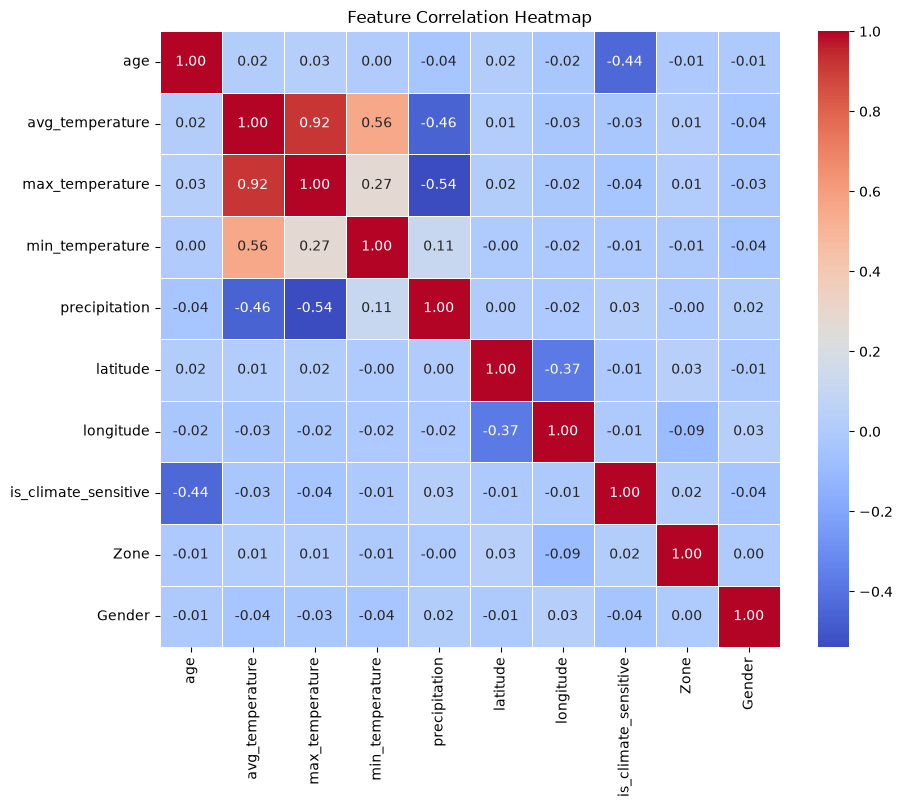

In [107]:
corr_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5
)
plt.title('Feature Correlation Heatmap')
plt.show()

In [108]:
df['temp_range'] = df['max_temperature'] - df['min_temperature']
df.drop(columns=['max_temperature', 'min_temperature'], inplace=True)

df.head()

,deathdate,age,avg_temperature,precipitation,latitude,longitude,is_climate_sensitive,Zone,Gender,temp_range
0,2007-10-02,30.0,21.137037,0.951601,0.584646,33.546344,1,1,1,7.117375
1,2008-01-05,2.0,24.062790,0.053352,0.549565,33.490326,1,1,1,10.334814
2,2008-02-14,31.0,22.407868,0.090349,0.573420,33.483655,1,1,0,8.633080
3,2008-02-15,1.0,23.315198,0.286814,0.549565,33.490326,1,1,0,9.101181
4,2008-02-15,69.0,23.315198,0.286814,1.072343,34.226647,0,1,0,9.101181


In [109]:


# 1. Heat Stress & Volatility Ratios
df['heat_stress_index'] = df['avg_temperature'] * df['precipitation']
df['temp_volatility_ratio'] = df['temp_range'] / (df['avg_temperature'] + 1e-5)

# 2. Regional Climate Anomalies (Grouped by Zone)
df['temp_zone_anomaly'] = df['avg_temperature'] - df.groupby('Zone')['avg_temperature'].transform('mean')
df['precip_zone_anomaly'] = df['precipitation'] - df.groupby('Zone')['precipitation'].transform('mean')

# 3. Demographic Risk Interaction
df['age_temp_interaction'] = df['age'] * df['avg_temperature']

In [110]:
# Simple One-Hot Encoding for Zone and Gender
df = pd.get_dummies(df, columns=['Zone', 'Gender'], drop_first=True)

In [111]:
X = df.drop(['is_climate_sensitive'], axis='columns')
y = df['is_climate_sensitive']

In [112]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [113]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [114]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.drop(columns=['deathdate']))
X_test_scaled = scaler.transform(X_test.drop(columns=['deathdate']))
X_test_scaled = scaler.transform(X_test.drop(columns=['deathdate']))

In [115]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [116]:
import xgboost as xgb

In [117]:
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_pca,
    y_train,
    eval_set=[(X_test_pca, y_test)],
    verbose=False
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [118]:
xgb_model.score(X_test_pca, y_test)

0.7015873015873015